---
title: "A Study on the Birthday Problem"
date: "2025-08-03"
toc: true
tags: [math]
sitemap:
    changefreq: never
    priority: 1.0
categories: [study]
description: 本文介绍了生日问题, 包括问题的定义, 极端情况, 穷举法, 对立事件的概率以及 Python 模拟. 本文是对<普林斯顿概率论>一书中相关内容的学习笔记.
---

## 问题的定义

**定义**: 房间里有多少人才能保证其中至少两个人的生日在同一天的概率不小于 50%?

**更严格的定义**: 如果每个人的出生日期都是互相独立的, 并且每个人都等可能的出生在一年中的任何一天 (假设不存在闰年), 房间里有多少人才能保证其中至少两个人的生日在同一天的概率不小于 50%?

更严格的定义通过添加一些前提条件，避免了一些在现实生活中可能发生的特殊情况，例如两个人的生日相关联，知道了一个人的生日就能猜出另一个人的生日 (双胞胎); 或者生日分布不均匀, 来自某个月份的人比来自其他月份的人更多 (某个星座的聚会). 添加前提条件可以排除这些特殊情况, 因为通过讨论得出来的一般结论并不适用于这些特殊情况.

## 极端情况

考虑如果房间里只有一个人, 那么有两个人生日相同的概率为 0, 而如果房间里有 366 个人, 那么有两个人生日相同的概率则为 100%. 因为假如前 365 个人的生日都不同, 那么这些人就一定占用了一年中所有的时间, 这样无论第 366 个人是哪天出生, 都一定会和前 365 个人中的某个人的生日相同. 此外, 如果房间里有 183 个生日不同的人, 那么有不小于 50% ($\frac{183}{365} \approx 50.14\%$) 的概率第 184 个人和前面 183 个人中的某个人生日相同. 因此可以确定答案就在 2 和 184 之间.

## 穷举法

假设有 n 个人在房间中, 当 n 等于 2 时, 两个人生日组合的总数是 $365\times365$, 其中两个人生日相同的情况的数量是 $365$, 因此当房间中有两个人时, 两个人生日相同的概率为 $\frac{365}{365\times365}\approx0.27\%$. 当 n 等于 3 时,三个人的生日组合的总数是 $365\times365\times365=48627125$, 而至少两个人生日相同有: 前两个人生日相同而第三个人生日不同, 或者第一个和第三个人生日相同而第二个人生日不同,或者后两个人生日相同而第一个人生日不同, 或者三个人的生日都相同, 这四种情况. 总数是: $365\times364\times3+365=398945$, 因此当 n 等于 3 时, 至少两个人生日相同的概率为 $\frac{398945}{48627125}\approx0.82\%$.

## 对立事件的概率

当 n 越来越大时, 需要考虑的情况更多, 容易重复计数某些情况, 或者漏掉某些情况. 此时, 可以计算对立事件的概率. 求出相对好求的对立事件的概率 $P$ 后, 当前事件的概率为 $1-P$. 对于当前问题来说, 事件为: 房间内有 n 个人, 存在生日相同的两人. 对立事件为: 房间内有 n 个人, 不存在生日相同的两人, 换句话说, 每个人的生日都不相同.

当 n 等于 1 时, 这个人可以取一年中的任意一天出生, 因此概率为 $\frac{365}{365}$, 也就是 $1$. 当 n 等于 2 时, 由于第一个人的存在, 第二个人只能选择 364 天中的一天, 每个人的生日都不同的概率为 $\frac{365}{365}\times\frac{364}{365}$, 因为已经假设每个人的生日都是独立的, 因此两个事件的联合概率就是两个事件概率的乘积. n 等于 3 时, 概率为:

$$
\frac{365}{365}\times\frac{364}{365}\times\frac{364}{365}
$$

因此, 当房间内有 n 个人时, 概率为:

$$
\frac{365}{365}\times\frac{364}{365}\times ... \times \frac{365-(n-1)}{365}
$$

改写为连乘的形式:

$$
\frac{365}{365}\times\frac{364}{365}\times ... \times \frac{365-(n-1)}{365} = \prod_{k=0}^{n-1}\frac{365-k}{365}
$$

进一步改写为阶乘的形式:

$$
\prod_{k=0}^{n-1}\frac{365-k}{365}=\frac{365\times...\times(365-(n-1))}{365^n}\times\frac{(365-n)!}{(365-n)!}=\frac{365!}{365^n\times(365-n)!}
$$

以上计算的是: 当房间内有 n 个人时, 所有人生日都不相同的概率. 记这个概率为 $P$, 那么至少有两个人生日相同的概率为 $1-P$. 通过计算, 当 n 为 2 时, 结果大约为 $0.27\%$, 与之前通过穷举法计算出的结果相同.

## Python 模拟

尽管阶乘公式看起来更美观，但是在计算时会导致数字过大, 不方便计算机处理. 因此在程序中还是使用了连乘的方式, 这种方式的好处是, 可以保存每一步的结果, 因此每一步只需要一次乘法运算.


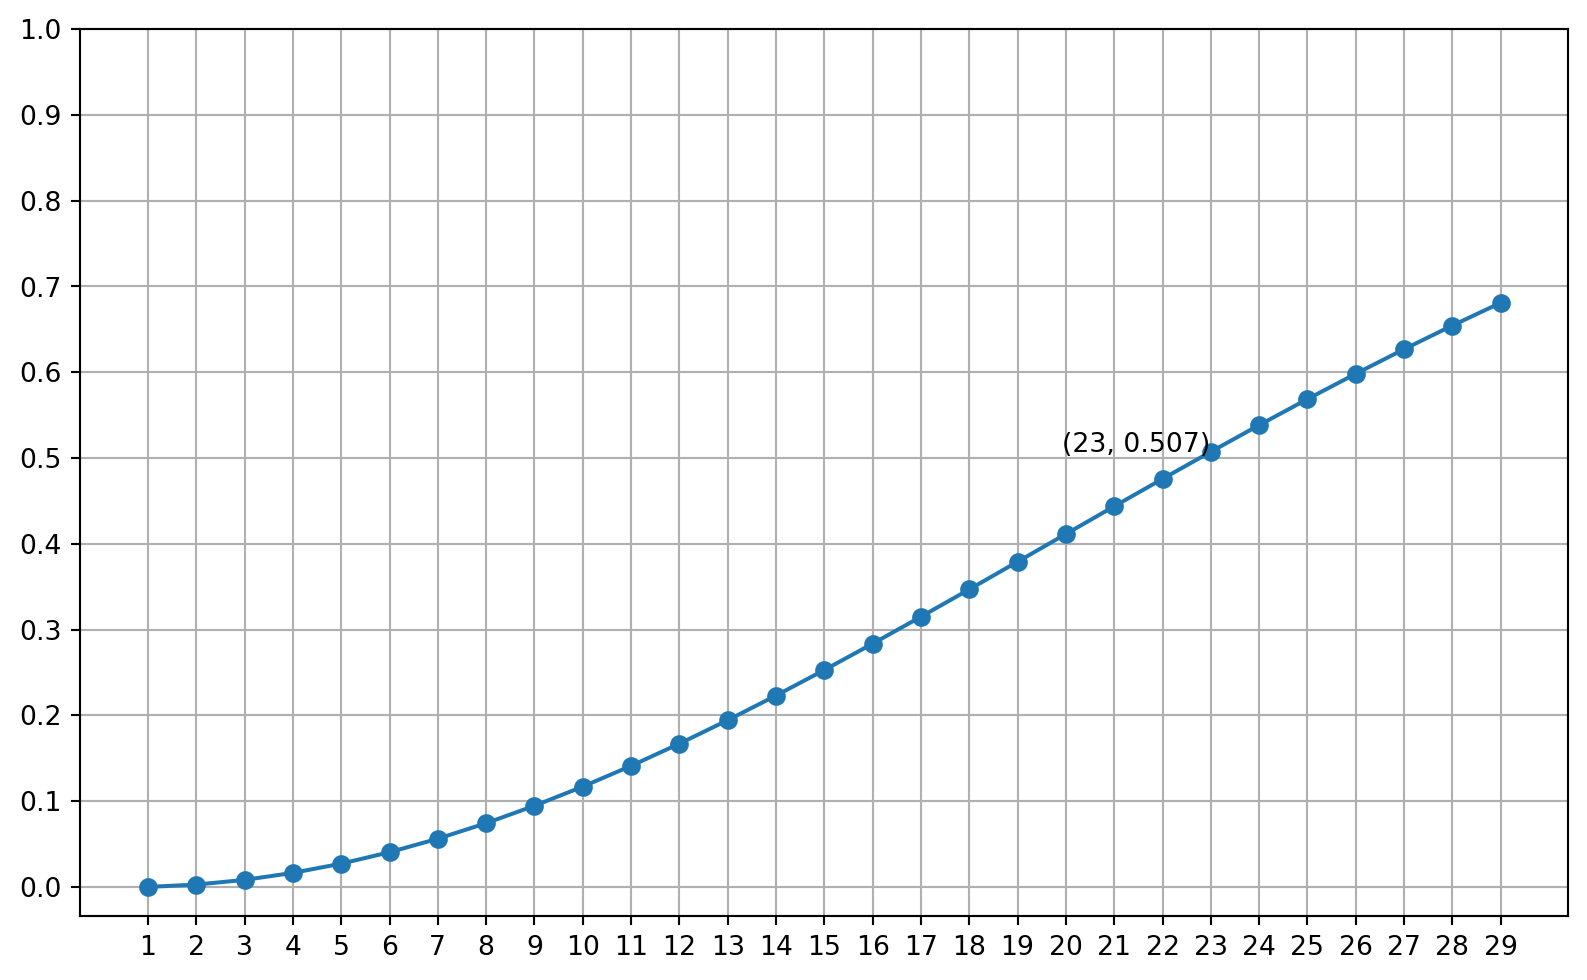

In [1]:
import matplotlib.pyplot as plt
import numpy as np

p = [0.0]
factor = 1.0
for i in range(2, 30):
    new_factor = factor * ((365 - i + 1) / 365)
    p.append(1 - new_factor)
    factor = new_factor

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 30), p, marker='o')
plt.annotate(f'(23, {p[22]:.3f})', (23, p[22]), ha='right')
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(np.arange(1, 30, 1))
plt.grid(True, which='both')
plt.show()

## 推广

当前的问题可以转换为如下的形式: 一个随机试验共有 D 种可能的结果, 并且每种结果出现的概率是相等的, 那么需要进行多少次试验才能使"至少两次试验的结果相同"的概率为 50%? 这个结果和 D 有关, 如果 D 很小, 那么可能很少的次数就会重复. 最极端的情况, D 等于 2, 那么第三次实验必然重复. 反之, 如果 D 很大, 那么就需要多次实验, 重复的概率才会显著增加. 那么假如目标概率已经确定 (50%), 当 D 变化时, 试验次数如何变化? 他们之间的关系是什么? 是否是线性关系, 或者其他关系? 下文通过推导公式: 房间内有 n 个人时, 所有人生日都不同的事件的概率:

$$
P = \prod_{k=0}^{n-1}\frac{365-k}{365}
$$

求出了一个近似的解析式.

首先,

$$
P = \prod_{k=0}^{n-1}\frac{365-k}{365}=\prod_{k=0}^{n-1}1-\frac{k}{365}
$$

对等式两端取对数，

$$
ln{P} = \sum_{k=0}^{n-1}ln{(1-\frac{k}{365})}
$$

由于当 x 足够小时, $ln(1-x) \approx -x$, 因此:

$$
ln{P} \approx \sum_{k=0}^{n-1}-\frac{k}{365}
$$

由求和公式:

$$
ln{P} \approx \frac{n(n-1)}{-365 \times 2}
$$

事件房间内至少有两人生日相等的概率为$1-P$. 设定这个事件的概率为 50%, 即 $P=\frac{1}{2}$.

$$
ln{\frac{1}{2}} \approx \frac{n(n-1)}{-365 \times 2}
$$

$$
-ln{2} \approx \frac{n(n-1)}{-365 \times 2}
$$

将 $n(n-1)$ 近似为 $(n-\frac{1}{2})^2$,

$$
(n-\frac{1}{2})^2 \approx 2\times365\times ln{2}
$$

$$
n \approx \frac{1}{2} + \sqrt{2\times365\times ln{2}}
$$

综上, 如果一年中有 D 天, 那么使房间内至少有两个人生日相等的概率为 50% 的人数大约是 $\frac{1}{2} + \sqrt{D\times2ln{2}}$. 从这个近似的表达式可以看出, 可能的结果的数量 D 与 试验次数 n 的关系大概是 $\frac{1}{2}$ 方的关系. 此外, 因为在计算中使用了泰勒展开, 所以 D 越大, 误差就越小.

以下代码使用新的近似的公式计算了 D 从 2 到 10000 时, n 的变化.


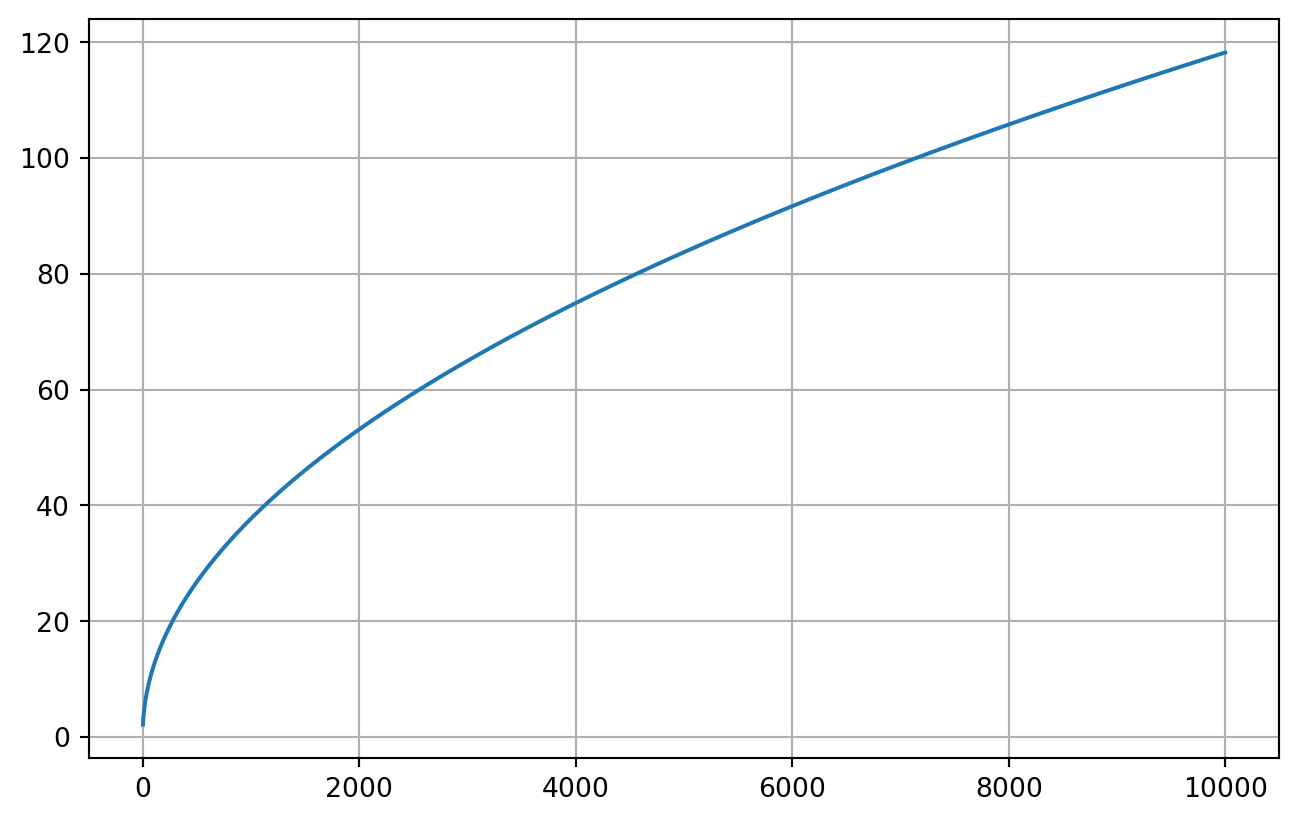

In [2]:
import matplotlib.pyplot as plt
import numpy as np

D_arr = np.arange(2, 10000)
n_arr = []

log2 = np.log(2)

for d in D_arr:
    n_arr.append(0.5 + np.sqrt(2 * log2 * d))

plt.plot(D_arr, n_arr, marker=',')
plt.grid(True, which='both')
plt.show()